<a href="https://colab.research.google.com/github/AbgnerM/Machine-Learning-Project/blob/FinalCode/chess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt

In [ ]:
file_path = "positions.csv"

data = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "nikitricky/chess-positions",
    file_path
)


print("First 5 records:")
print(data.head())

print(f"\nDataset size: {len(data)} positions")
print(f"Columns available: {list(data.columns)}")


Using Colab cache for faster access to the 'chess-positions' dataset.


/usr/local/lib/python3.12/dist-packages/kagglehub/pandas_datasets.py:92: DtypeWarning: Columns (12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


First 5 records:
                                                 fen playing  score  mate  \
0  rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...    e2e4  -35.0   NaN   
1  rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...    e7e6   36.0   NaN   
2  rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBN...    d2d4  -27.0   NaN   
3  rnbqkbnr/p1pp1ppp/1p2p3/8/3PP3/8/PPP2PPP/RNBQK...    b7b6   81.0   NaN   
4  rnbqkbnr/p1pp1ppp/1p2p3/8/3PP3/P7/1PP2PPP/RNBQ...    a2a3  -65.0   NaN   

   depth   game_id        date      time  white    black white_result  \
0     20  j1dkb5dw  2012.12.31  23:01:03  BFG9k  mamalak            1   
1     22  j1dkb5dw  2012.12.31  23:01:03  BFG9k  mamalak            1   
2     24  j1dkb5dw  2012.12.31  23:01:03  BFG9k  mamalak            1   
3     20  j1dkb5dw  2012.12.31  23:01:03  BFG9k  mamalak            1   
4     22  j1dkb5dw  2012.12.31  23:01:03  BFG9k  mamalak            1   

  black_result white_elo black_elo                           opening  \
0        

In [ ]:
print("\nColumn names and types:")
print(data.dtypes)


print("POSITION DATA SUMMARY")

print(f"\nTotal positions: {len(data):,}")
print(f"Positions with score (centipawns): {data['score'].notna().sum():,}")

print("\nScore Distribution (non-mate positions)")
print(data['score'].describe())


print("\n--- Who's to Move ---")
print(data['playing'].value_counts())


Column names and types:
fen              object
playing          object
score           float64
mate            float64
depth             int64
game_id          object
date             object
time             object
white            object
black            object
white_result     object
black_result     object
white_elo        object
black_elo        object
opening          object
time_control     object
termination      object
dtype: object
POSITION DATA SUMMARY

Total positions: 1,091,078
Positions with score (centipawns): 981,566

Score Distribution (non-mate positions)
count    981566.000000
mean         20.746932
std         651.694704
min      -20000.000000
25%        -129.000000
50%           7.000000
75%         197.000000
max       20000.000000
Name: score, dtype: float64

--- Who's to Move ---
playing
g1f3     13315
g8f6     12302
e2e4     12141
d2d4     11044
b8c6     10931
         ...  
e7e8r        1
c2b1r        1
b7b8n        1
d7d8n        1
b7b8b        1
Name: count

In [ ]:
def create_evaluation(row):
    if pd.notna(row['score']):
        return row['score']
    elif pd.notna(row['mate']):
        # Convert mate-in-N to a large score
        # Positive mate = good for white, negative = good for black
        mate_value = row['mate']
        if mate_value > 0:
            return 10000 - abs(mate_value) * 10
        else:
            return -10000 + abs(mate_value) * 10
    else:
        return 0
data['evaluation'] = data.apply(create_evaluation, axis=1)

print("Evaluation column created!")
print(f"Positions with evaluation: {data['evaluation'].notna().sum():,}")
print("\nEvaluation statistics:")
print(data['evaluation'].describe())

Evaluation column created!
Positions with evaluation: 1,091,078

Evaluation statistics:
count    1.091078e+06
mean     9.128649e+01
std      3.205311e+03
min     -2.000000e+04
25%     -1.750000e+02
50%      8.000000e+00
75%      2.710000e+02
max      2.000000e+04
Name: evaluation, dtype: float64


In [ ]:
def fen_to_features(fen):
    """
    Convert FEN string to simple numerical features
    """
    #split FEN into components
    parts = fen.split()
    board = parts[0]
    turn = parts[1] if len(parts) > 1 else 'w'
    castling = parts[2] if len(parts) > 2 else '-'

    #basic piece balues
    piece_values = {
        'P': 1, 'N': 3, 'B': 3, 'R': 5, 'Q': 9, 'K': 0,
        'p': -1, 'n': -3, 'b': -3, 'r': -5, 'q': -9, 'k': 0
    }

    # count material
    material_balance = sum(piece_values.get(char, 0) for char in board)

    # count every type
    white_pawns = board.count('P')
    black_pawns = board.count('p')
    white_knights = board.count('N')
    black_knights = board.count('n')
    white_bishops = board.count('B')
    black_bishops = board.count('b')
    white_rooks = board.count('R')
    black_rooks = board.count('r')
    white_queens = board.count('Q')
    black_queens = board.count('q')

    #see turns (1 for w -1 for b)
    turn_value = 1 if turn == 'w' else -1

    #castling
    can_castle_white_kingside = 1 if 'K' in castling else 0
    can_castle_white_queenside = 1 if 'Q' in castling else 0
    can_castle_black_kingside = 1 if 'k' in castling else 0
    can_castle_black_queenside = 1 if 'q' in castling else 0

    return [
        material_balance,
        white_pawns, black_pawns,
        white_knights, black_knights,
        white_bishops, black_bishops,
        white_rooks, black_rooks,
        white_queens, black_queens,
        turn_value,
        can_castle_white_kingside, can_castle_white_queenside,
        can_castle_black_kingside, can_castle_black_queenside
    ]

In [ ]:
# Create binary classification target
# Positions with positive evaluation favor white (1), negative favor black (0)
y_binary = (data['evaluation'] > 0).astype(int)

print("Binary classification target created")
print(f"White advantage positions: {(y_binary == 1).sum():,}")
print(f"Black advantage positions: {(y_binary == 0).sum():,}")
print(f"Class balance: {(y_binary == 1).sum() / len(y_binary) * 100:.1f}% white advantage")

Binary classification target created
White advantage positions: 565,117
Black advantage positions: 525,961
Class balance: 51.8% white advantage


In [ ]:
print("Converting positions to features")
X = np.array([fen_to_features(fen) for fen in data['fen']])
y = data['evaluation'].values

# Normalize features
scaler_X = StandardScaler()
X = scaler_X.fit_transform(X)

# Normalize target variable
scaler_y = StandardScaler()
y = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("Conversion complete!")

Converting positions to features

Feature matrix shape: (1091078, 16)
Target shape: (1091078,)
Conversion complete!


In [ ]:

#split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]:,}")
print(f"Test set size: {X_test.shape[0]:,}")



Training set size: 872,862
Test set size: 218,216


In [ ]:
# Split data for logistic regression (using original normalized X)
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"Training set size: {len(X_train_lr):,} samples")
print(f"Testing set size: {len(X_test_lr):,} samples")

Training set size: 872,862 samples
Testing set size: 218,216 samples


In [ ]:
print("Training Linear Regression...")
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
print("Linear Regression training complete")

Training Linear Regression...
Linear Regression training complete


In [ ]:
print("Training Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=9,
    min_samples_split=200,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_model.fit(X_train, y_train)
print("Random Forest training complete")

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  2.1min


Random Forest training complete


[Parallel(n_jobs=-1)]: Done 150 out of 150 | elapsed:  6.6min finished


In [ ]:
print("Training Gradient Boosting...")
gb_model = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    verbose=0
)
gb_model.fit(X_train, y_train)
print("Gradient Boosting training complete")

Training Gradient Boosting...
Gradient Boosting training complete


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Training Logistic Regression...")
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train_lr, y_train_lr)
print("Logistic Regression training complete")

Training Logistic Regression...
Logistic Regression training complete


In [ ]:
# Make predictions
y_pred_lr = log_reg_model.predict(X_test_lr)

# Evaluate the model
accuracy = accuracy_score(y_test_lr, y_pred_lr)

print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(f"\nModel Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_lr, y_pred_lr, target_names=['Black Advantage', 'White Advantage']))

# Confusion Matrix
cm = confusion_matrix(y_test_lr, y_pred_lr)
print("\nConfusion Matrix:")
print(f"{'':>20} {'Predicted Black':<20} {'Predicted White':<20}")
print(f"{'Actual Black':<20} {cm[0,0]:<20} {cm[0,1]:<20}")
print(f"{'Actual White':<20} {cm[1,0]:<20} {cm[1,1]:<20}")

LOGISTIC REGRESSION RESULTS

Model Accuracy: 0.5678

Classification Report:
                 precision    recall  f1-score   support

Black Advantage       0.55      0.57      0.56    105192
White Advantage       0.59      0.56      0.57    113024

       accuracy                           0.57    218216
      macro avg       0.57      0.57      0.57    218216
   weighted avg       0.57      0.57      0.57    218216


Confusion Matrix:
                     Predicted Black      Predicted White     
Actual Black         60337                44855               
Actual White         49465                63559               


In [ ]:
#predictions (normalized)
y_pred_linear = linear_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)

# Denormalize predictions and test set for meaningful metrics
y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()
y_pred_linear_original = scaler_y.inverse_transform(y_pred_linear.reshape(-1, 1)).ravel()
y_pred_rf_original = scaler_y.inverse_transform(y_pred_rf.reshape(-1, 1)).ravel()
y_pred_gb_original = scaler_y.inverse_transform(y_pred_gb.reshape(-1, 1)).ravel()

#metrics for LR
mae_linear = mean_absolute_error(y_test_original, y_pred_linear_original)
rmse_linear = np.sqrt(mean_squared_error(y_test_original, y_pred_linear_original))
r2_linear = r2_score(y_test_original, y_pred_linear_original)

#metrics for RF
mae_rf = mean_absolute_error(y_test_original, y_pred_rf_original)
rmse_rf = np.sqrt(mean_squared_error(y_test_original, y_pred_rf_original))
r2_rf = r2_score(y_test_original, y_pred_rf_original)

#metrics for GB
mae_gb = mean_absolute_error(y_test_original, y_pred_gb_original)
rmse_gb = np.sqrt(mean_squared_error(y_test_original, y_pred_gb_original))
r2_gb = r2_score(y_test_original, y_pred_gb_original)


print("\n LINEAR REGRESSION")
print(f"  MAE (centipawns):  {mae_linear:.2f}")
print(f"  RMSE (centipawns): {rmse_linear:.2f}")
print(f"  R² Score:          {r2_linear:.3f}")

print("\n RANDOM FOREST")
print(f"  MAE (centipawns):  {mae_rf:.2f}")
print(f"  RMSE (centipawns): {rmse_rf:.2f}")
print(f"  R² Score:          {r2_rf:.3f}")

print("\n GRADIENT BOOSTING")
print(f"  MAE (centipawns):  {mae_gb:.2f}")
print(f"  RMSE (centipawns): {rmse_gb:.2f}")
print(f"  R² Score:          {r2_gb:.3f}")


print("\nCLASSIFICATION MODEL")
print("\n LOGISTIC REGRESSION")
print(f"  Accuracy:          {accuracy:.4f}")
print(f"  Precision (White): {classification_report(y_test_lr, y_pred_lr, output_dict=True)['1']['precision']:.4f}")
print(f"  Recall (White):    {classification_report(y_test_lr, y_pred_lr, output_dict=True)['1']['recall']:.4f}")
print(f"  F1-Score (White):  {classification_report(y_test_lr, y_pred_lr, output_dict=True)['1']['f1-score']:.4f}")

print("\n" + "=" * 60)



[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.5s
[Parallel(n_jobs=2)]: Done 150 out of 150 | elapsed:    1.5s finished



 LINEAR REGRESSION
  MAE (centipawns):  1288.10
  RMSE (centipawns): 3192.37
  R² Score:          0.000

 RANDOM FOREST
  MAE (centipawns):  842.19
  RMSE (centipawns): 2011.94
  R² Score:          0.603

 GRADIENT BOOSTING
  MAE (centipawns):  1007.34
  RMSE (centipawns): 2194.67
  R² Score:          0.528

CLASSIFICATION MODEL

 LOGISTIC REGRESSION
  Accuracy:          0.5678
  Precision (White): 0.5863
  Recall (White):    0.5623
  F1-Score (White):  0.5741



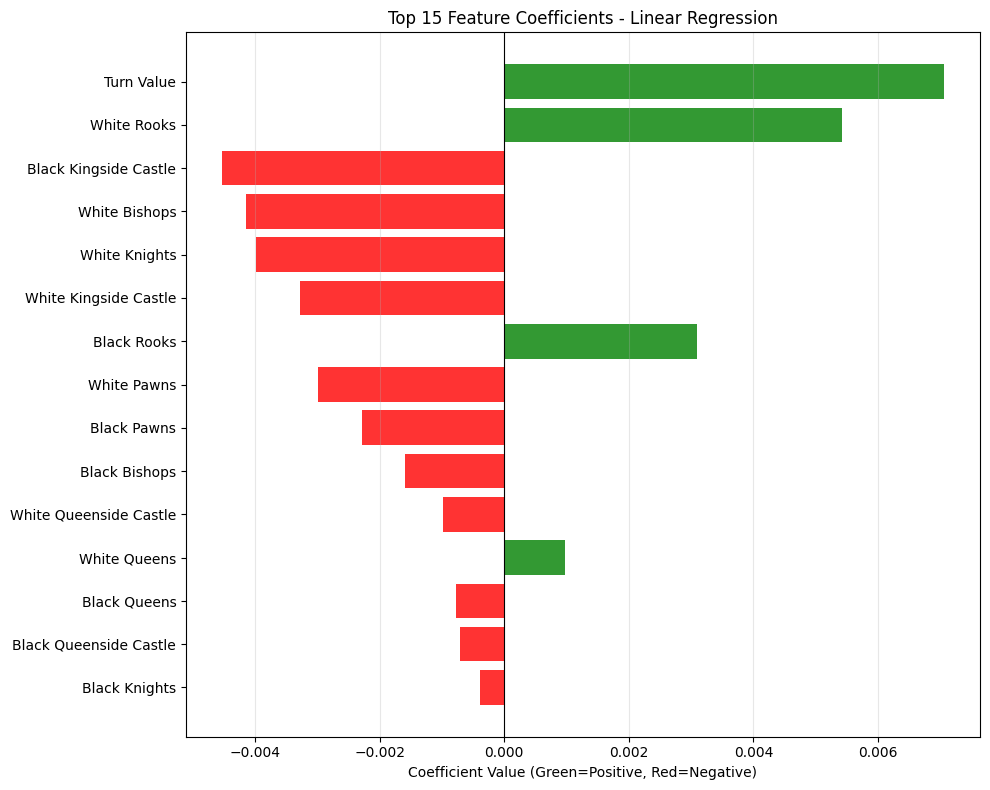

In [ ]:
# Linear Regression Feature Coefficients
coefficients = linear_model.coef_

feature_names = [
    'Material Balance',
    'White Pawns', 'Black Pawns',
    'White Knights', 'Black Knights',
    'White Bishops', 'Black Bishops',
    'White Rooks', 'Black Rooks',
    'White Queens', 'Black Queens',
    'Turn Value',
    'White Kingside Castle', 'White Queenside Castle',
    'Black Kingside Castle', 'Black Queenside Castle'
]

# Calculate absolute values for importance ranking
abs_coefficients = np.abs(coefficients)

# Create bar plot
fig, ax = plt.subplots(figsize=(10, 8))

top_n = 15
top_indices = np.argsort(abs_coefficients)[::-1][:top_n]
top_names = [feature_names[i] for i in top_indices]
top_coef = coefficients[top_indices]  # Keep original sign for direction

y_pos = np.arange(len(top_names))

# Color bars based on positive/negative coefficient
colors = ['green' if c > 0 else 'red' for c in top_coef]

ax.barh(y_pos, top_coef, align='center', color=colors, alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_names)
ax.invert_yaxis()
ax.set_xlabel('Coefficient Value (Green=Positive, Red=Negative)')
ax.set_title(f'Top {top_n} Feature Coefficients - Linear Regression')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

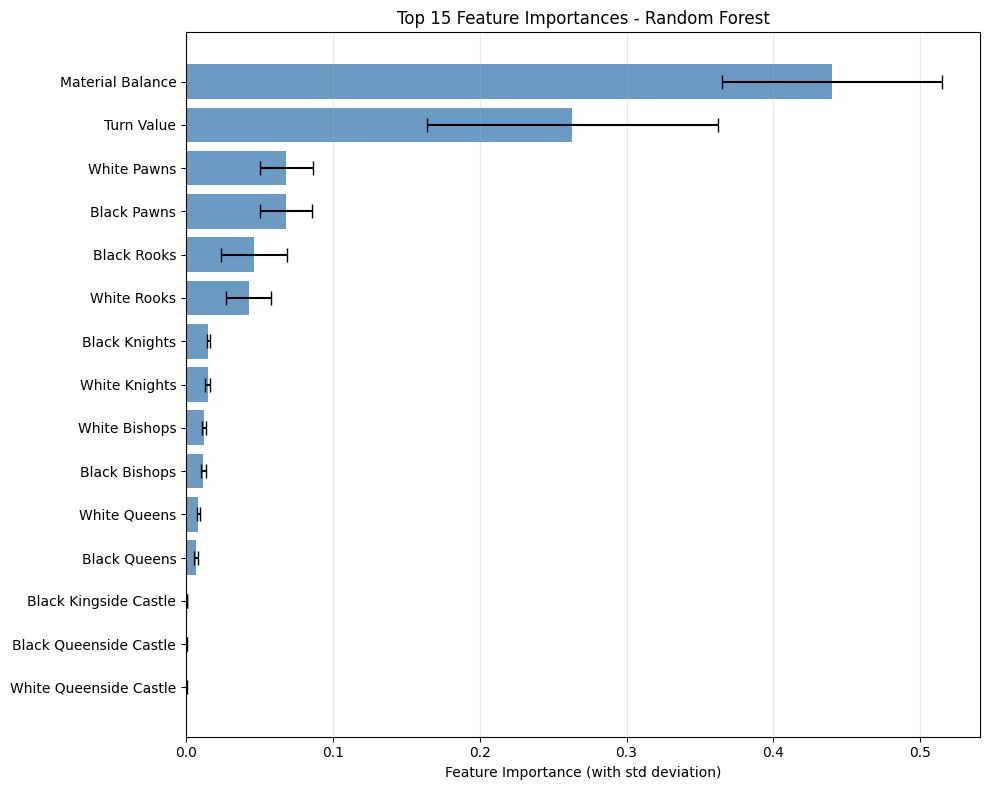

In [ ]:


# Random Forest Feature Importances
importances = rf_model.feature_importances_

feature_names = [
    'Material Balance',
    'White Pawns', 'Black Pawns',
    'White Knights', 'Black Knights',
    'White Bishops', 'Black Bishops',
    'White Rooks', 'Black Rooks',
    'White Queens', 'Black Queens',
    'Turn Value',
    'White Kingside Castle', 'White Queenside Castle',
    'Black Kingside Castle', 'Black Queenside Castle'
]

# Calculate standard deviation of importances across all trees
std = np.std([tree.feature_importances_ for tree in rf_model.estimators_], axis=0)

# Create bar plot with error bars
fig, ax = plt.subplots(figsize=(10, 8))

top_n = 15
top_indices = np.argsort(importances)[::-1][:top_n]
top_names = [feature_names[i] for i in top_indices]
top_importances = importances[top_indices]
top_std = std[top_indices]

y_pos = np.arange(len(top_names))
ax.barh(y_pos, top_importances, xerr=top_std, align='center',
        color='steelblue', alpha=0.8, ecolor='black', capsize=5)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_names)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (with std deviation)')
ax.set_title(f'Top {top_n} Feature Importances - Random Forest')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Get feature coefficients
feature_names = [
    'Material Balance',
    'White Pawns', 'Black Pawns',
    'White Knights', 'Black Knights',
    'White Bishops', 'Black Bishops',
    'White Rooks', 'Black Rooks',
    'White Queens', 'Black Queens',
    'Turn Value',
    'White Kingside Castle', 'White Queenside Castle',
    'Black Kingside Castle', 'Black Queenside Castle'
]

coefficients = log_reg_model.coef_[0]

# Create DataFrame for feature importance
feature_importance_lr = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute_Coefficient': np.abs(coefficients)
})

# Sort by absolute coefficient value
feature_importance_lr = feature_importance_lr.sort_values(by='Absolute_Coefficient', ascending=False)

print("\nLogistic Regression Feature Importance:")
print(feature_importance_lr.to_string(index=False))


Logistic Regression Feature Importance:
               Feature  Coefficient  Absolute_Coefficient
            Turn Value     0.247672              0.247672
           Black Pawns     0.046205              0.046205
           White Pawns     0.036153              0.036153
         White Knights     0.023294              0.023294
           White Rooks     0.023280              0.023280
           Black Rooks     0.018592              0.018592
         Black Knights     0.014637              0.014637
         White Bishops     0.014533              0.014533
Black Queenside Castle    -0.013747              0.013747
          White Queens     0.010571              0.010571
 Black Kingside Castle    -0.009862              0.009862
 White Kingside Castle    -0.009805              0.009805
         Black Bishops     0.009789              0.009789
          Black Queens     0.008848              0.008848
      Material Balance     0.008645              0.008645
White Queenside Castle    -0.00

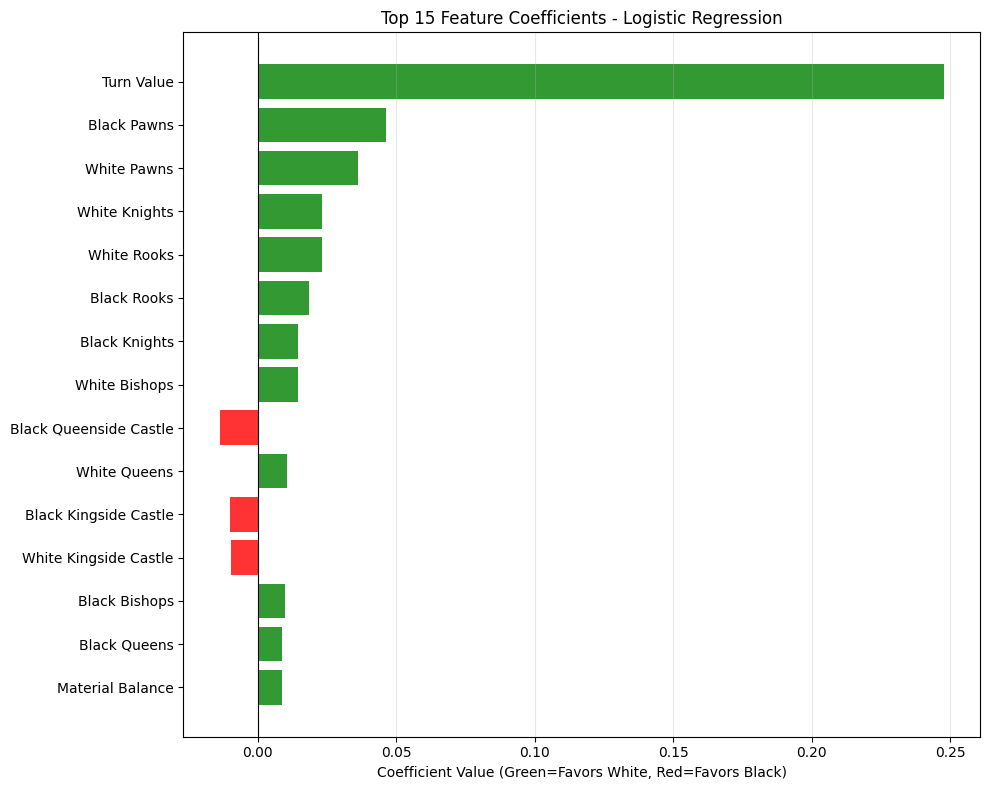

In [ ]:
# Plot feature importance for Logistic Regression
fig, ax = plt.subplots(figsize=(10, 8))

top_n = 15
top_features = feature_importance_lr.head(top_n)

y_pos = np.arange(len(top_features))
colors = ['green' if c > 0 else 'red' for c in top_features['Coefficient']]

ax.barh(y_pos, top_features['Coefficient'], align='center', color=colors, alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_features['Feature'])
ax.invert_yaxis()
ax.set_xlabel('Coefficient Value (Green=Favors White, Red=Favors Black)')
ax.set_title('Top 15 Feature Coefficients - Logistic Regression')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

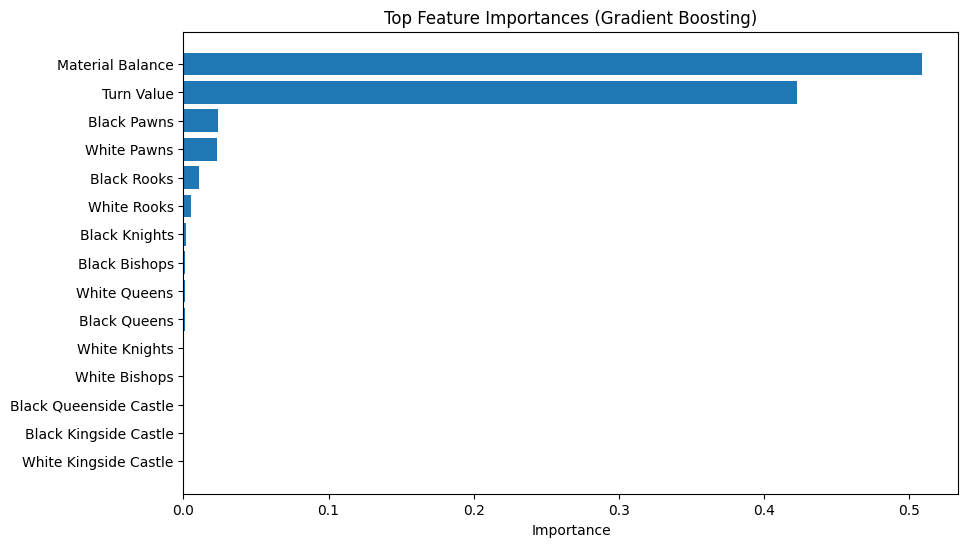

In [ ]:
feature_names = [
    'Material Balance',
    'White Pawns', 'Black Pawns',
    'White Knights', 'Black Knights',
    'White Bishops', 'Black Bishops',
    'White Rooks', 'Black Rooks',
    'White Queens', 'Black Queens',
    'Turn Value',
    'White Kingside Castle', 'White Queenside Castle',
    'Black Kingside Castle', 'Black Queenside Castle'
]
importances = gb_model.feature_importances_

sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.barh(
    [feature_names[i] for i in sorted_idx][:15],
    importances[sorted_idx][:15]
)
plt.gca().invert_yaxis()
plt.title("Top Feature Importances (Gradient Boosting)")
plt.xlabel("Importance")
plt.show()

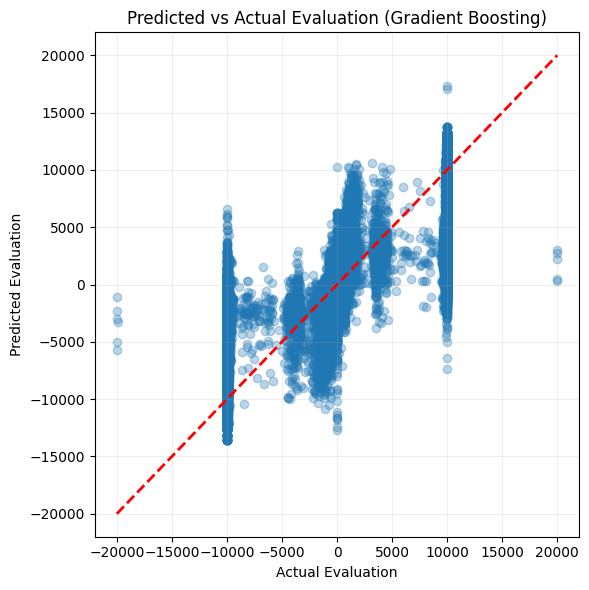

In [ ]:

# use your gradient boosting outputs
y_true = y_test_original
y_pred = y_pred_gb_original

plt.figure(figsize=(6, 6))

plt.scatter(y_true, y_pred, alpha=0.3)

min_val = min(np.min(y_true), np.min(y_pred))
max_val = max(np.max(y_true), np.max(y_pred))

plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.title("Predicted vs Actual Evaluation (Gradient Boosting)")
plt.xlabel("Actual Evaluation")
plt.ylabel("Predicted Evaluation")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()